# DANSy Analysis of fusion genes in the Cancer Cell Line Encyclopedia

Here to expand upon the fusion analysis done on The Cancer Genome Atlas (TCGA), we will now explore fusions within the Cancer Cell Line Encyclopedia (CCLE). Using this analysis we will see how many of the fusions we have in vitro models of impact the domain n-gram network that can be further explored in RNA-Seq/proteomic results.

There is a section that looks at the expression based changes in gene effect (dependency scores) from dep map, which is has been prototyped [here](#dependency_development)

Note: as part of this some of the order is not the most intuitive, but a refined set of analysis can be found at [Refined Analysis](#refined_analysis)

In [55]:
import dansy
import numpy as np
import pandas as pd
import fusionClasses as fc
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import itertools
import scipy.stats as stats
from collections import Counter

In [56]:
# Now let's set up a handful of matplotlib default values
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 200


### Creating some common helper functions

<a id='helpers'> </a>

In [57]:
# For a handful of genes they lack an ensembl ID so will try to convert them, but otherwise will drop them
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
gene_conv = gene_conv.filter(['Gene stable ID', 'Gene name'], axis = 1).drop_duplicates()
conv_dict = dict(zip(gene_conv['Gene name'], gene_conv['Gene stable ID']))

def fix_ensembl(row, gene_pos, cnv = conv_dict):
    ensembl_name = f'gene{gene_pos}_ensembl'
    symbol_name =f'gene{gene_pos}_symbol'
    val = row[ensembl_name]
    gene_name = row[symbol_name]
    if val == '':
        
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    elif val in cnv.values():
        new_val = val
    else: # Double-check any that are not the current ENSEMBL ID
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    
    return new_val


## Start of analysis

In [3]:
# DANSy object of the full natural proteome
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0108.csv')
proteome_net = dansy.dansy(ref=ref_df, n=66)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [4]:
# Importing the CCLE information
ccle_fusions = pd.read_csv('CCLE_OmicsFusionFilteredSupplementary.csv', index_col=0)
ccle_model_info = pd.read_csv('CCLE_Model.csv')

# A little bit of pre-filtering to remove any of the out of frame fusions because predicting their domain architecture is not accurate
ccle_fusions = ccle_fusions[ccle_fusions['reading_frame'] != 'out-of-frame']

# Additionally removing low confidence fusions and any with FFPM value < 0.1 a general cutoff for fusion artifacts
ccle_fusions = ccle_fusions[ccle_fusions['confidence'] != 'low']
ccle_fusions = ccle_fusions[ccle_fusions['FFPM'] >= 0.1]

In [5]:
# Now let's create a new dataframe that has only relevant information for the time being that can then be passed on to create a fusion gene collection object.
dataOI = ccle_fusions.filter(['ModelID','CanonicalFusionName', 'gene1(ENS ID)', 'gene2(ENS ID)','strand1(gene/fusion)', 'strand2(gene/fusion)','breakpoint1', 'breakpoint2']).copy()


In [6]:
dataOI[['gene1_symbol','gene1_ensembl'] ]= dataOI['gene1(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI[['gene2_symbol','gene2_ensembl']] = dataOI['gene2(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI['gene1_symbol']=dataOI['gene1_symbol'].str.strip()
dataOI['gene2_symbol']=dataOI['gene2_symbol'].str.strip()
dataOI['gene1_ensembl']=dataOI['gene1_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['gene2_ensembl']=dataOI['gene2_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['strand1'] = dataOI['strand1(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI['strand2'] = dataOI['strand2(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI[['gene1_chr','gene1_pos']] = dataOI['breakpoint1'].str.split(':', n=1, expand=True)
dataOI[['gene2_chr','gene2_pos']] = dataOI['breakpoint2'].str.split(':', n=1, expand=True)
dataOI['gene1_pos']=dataOI['gene1_pos'].astype(int)
dataOI['gene2_pos']=dataOI['gene2_pos'].astype(int)


In [7]:
# For a handful of genes they lack an ensembl ID so will try to convert them, but otherwise will drop them
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
gene_conv = gene_conv.filter(['Gene stable ID', 'Gene name'], axis = 1).drop_duplicates()
conv_dict = dict(zip(gene_conv['Gene name'], gene_conv['Gene stable ID']))

In [9]:
dataOI['gene1_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 1) , axis=1)
dataOI['gene2_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 2) , axis=1)
dataOI.dropna(subset=['gene1_ensembl', 'gene2_ensembl'],inplace=True)

In [10]:
# Now with all the pre-filtering done let's run the DANSy fusion analysis
mappings = {'h_gene':'gene1_ensembl', 't_gene':'gene2_ensembl', 'h_chr':'gene1_chr', 't_chr':'gene2_chr', 'h_strand':'strand1', 't_strand':'strand2', 'name':'CanonicalFusionName', 'h_pos':'gene1_pos', 't_pos':'gene2_pos'}
ccle_fc = fc.fusionCollection(dataOI, mappings, add_cols=['ModelID'])

100%|██████████| 20601/20601 [01:25<00:00, 242.07it/s]


In [11]:
ccle_fc.perform_dansy_analysis(dansy_obj=proteome_net)
dansy_sum = ccle_fc.summarize_dansy_results()

100%|██████████| 4830/4830 [00:13<00:00, 359.03it/s]


There were 2118 fusion domain architectures previously found in the proteome.


<Axes: xlabel='dansy_impact', ylabel='percent'>

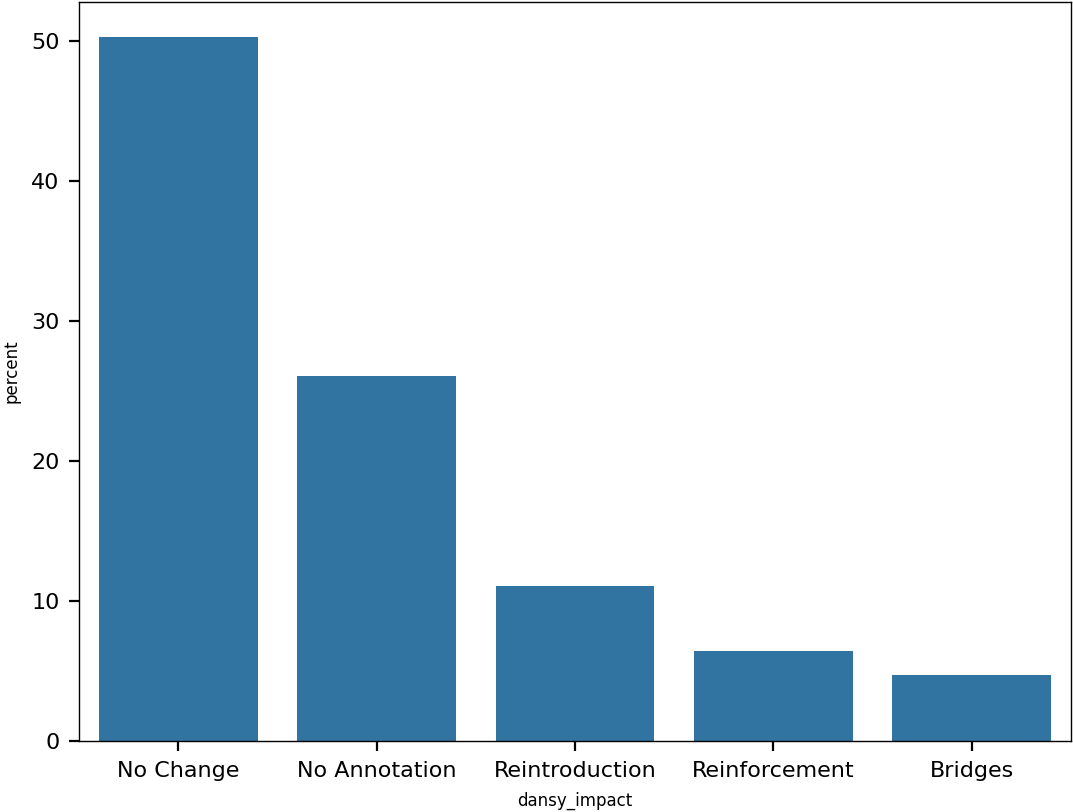

In [12]:
sns.countplot(dansy_sum, x = 'dansy_impact', stat='percent')

Very similar to what we show in TCGA is that most will lead to no differences to the domain n-gram network. Let's compare some of these to those found in the TCGA dataset.

In [13]:
# Importing the TCGA results
tcga_dansy_summary = pd.read_csv('TCGA_Fusion_DANSY_Summary.csv')

In [14]:
# Let's create new columns for the dansy results that combine the ENSEMBL IDs and then grab the domain architectures and dansy impacts
tcga_dansy_summary['ENSEMBL_Combo'] = tcga_dansy_summary['h_gene'].str.cat(tcga_dansy_summary['t_gene'], sep = '-')
dansy_sum['ENSEMBL_Combo'] = dansy_sum['h_gene'].str.cat(dansy_sum['t_gene'], sep = '-')
dansy_sum['Original_Index'] = dansy_sum['id'].apply(lambda x: int(x.split('_')[1]))

In [15]:
# Now let's check for the overlap between the two and just filter down the CCLE to those for the time being
ccle_filt = dansy_sum[dansy_sum['ENSEMBL_Combo'].isin(tcga_dansy_summary['ENSEMBL_Combo'])]

# And dropping any that have No Domain Annotations
ccle_filt = ccle_filt[ccle_filt['dansy_impact'] != 'No Annotation']

In [16]:
# Now let's make sure the ones that are left match the dansy impact and domain architecture in tcga

ccle_group = ccle_filt.groupby(['ENSEMBL_Combo', 'dansy_impact', 'domain_architecture'])
tcga_groups = tcga_dansy_summary.groupby(['ENSEMBL_Combo', 'dansy_impact', 'domain_architecture']).groups.keys()

idx_2_keep = []
groups_with_reps = []
for group, idx in ccle_group.groups.items():
    if group in tcga_groups:
        idx_2_keep.append(idx)
        groups_with_reps.append(group)

idx_2_keep = list(itertools.chain.from_iterable(idx_2_keep))

ccle_filt = ccle_filt.filter(idx_2_keep, axis = 0)

In [17]:
max_rep = None
cnt = 0
for group in groups_with_reps:
    x = ccle_group.get_group(group)
    if len(x) > cnt:
        max_rep = group
        cnt = len(x)

genes = max_rep[0].split('-')
inv_conv_dict = {v:k for k,v in conv_dict.items()}
gene1, gene2 = [inv_conv_dict[i] for i in genes]
print(f'The fusion gene {gene1}-{gene2} with a DANSy impact of {max_rep[1]} had the most representative cell lines at {cnt}')

The fusion gene BCR-ABL1 with a DANSy impact of Reinforcement had the most representative cell lines at 33


In [18]:
gene2lookoutfor=set()
for group in groups_with_reps:
    x = ccle_group.get_group(group)
    if len(x) > 5:
        max_rep = group
        cnt = len(x)

        genes = max_rep[0].split('-')
        gene1, gene2 = [inv_conv_dict[i] for i in genes]
        gene2lookoutfor.update([gene1,gene2])
        leg_dom = proteome_net.return_legible_ngram(max_rep[2])
        print(f'The fusion gene {gene1}-{gene2} with a DANSy impact of {max_rep[1]} and domain arch of {leg_dom} has {cnt} representative cell lines')

The fusion gene VMP1-RPS6KB1 with a DANSy impact of No Change and domain arch of Prot_kinase_dom|AGC-kinase_C has 6 representative cell lines
The fusion gene ABL1-BCR with a DANSy impact of No Change and domain arch of RhoGAP_dom has 21 representative cell lines
The fusion gene ABL1-BCR with a DANSy impact of No Change and domain arch of DH_dom|PH_domain|C2_dom|RhoGAP_dom has 6 representative cell lines
The fusion gene KANSL1-GAST with a DANSy impact of No Change and domain arch of Gastrin/CCK has 14 representative cell lines
The fusion gene FLNB-SLMAP with a DANSy impact of No Change and domain arch of CH_dom|CH_dom has 12 representative cell lines
The fusion gene YAP1-MAML2 with a DANSy impact of Bridges and domain arch of WW_dom|WW_dom|MAML2_TAD has 8 representative cell lines
The fusion gene CLTC-VMP1 with a DANSy impact of No Change and domain arch of Clathrin_H-chain_linker_core has 19 representative cell lines
The fusion gene SS18-SSX2 with a DANSy impact of No Change and domain

In [19]:
# Now let's grab the model information for these fusion information
modelsOI = ccle_filt.ModelID.unique()
ccle_fusion_lines = ccle_model_info[ccle_model_info['ModelID'].isin(modelsOI)]

In [20]:
# Fusion information that passed filters from above
fusionOI = ccle_fusions.filter(ccle_filt['Original_Index'], axis=0)
x = fusionOI.filter(['ModelID', 'CanonicalFusionName']).drop_duplicates()

In [21]:
sorted(Counter(x['CanonicalFusionName']).items(), key=lambda y:y[1],reverse=True)[0:10]

[('ABL1--BCR', 24),
 ('CLTC--VMP1', 17),
 ('ALK--EML4', 7),
 ('FGFR3--TACC3', 6),
 ('FLNB--SLMAP', 6),
 ('RPS6KB1--VMP1', 5),
 ('SS18--SSX2', 5),
 ('VAT1L--WWOX', 5),
 ('CD44--PDHX', 4),
 ('APBB2--RBM47', 4)]

In [22]:
ccle_proteomics = pd.read_csv('CCLE_proteomics_normalized.tsv')

In [23]:
# Let's get the column names and then find out how many of our fusion model candidates have proteomic data associated with them
prot_celllines = [i.split('_Ten')[0] for i in ccle_proteomics.columns if '_Ten' in i]

In [27]:
fusion_prot_lines = set(prot_celllines).intersection(ccle_fusion_lines['CCLEName'])
print(f'There are {len(fusion_prot_lines)} cell lines with fusion genes')

There are 62 cell lines with fusion genes


In [28]:
ccle_tpm = pd.read_csv('OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv', index_col=0)

In [29]:
fusion_tpm = ccle_tpm[ccle_tpm['ModelID'].isin(modelsOI)]

In [30]:
# Let's verify that all the cell lines with proteomics data has accesible TPM data as well
prot_lines = ccle_model_info[ccle_model_info['CCLEName'].isin(fusion_prot_lines)].ModelID
ovlerapping_lines = set(fusion_tpm.ModelID).intersection(prot_lines)
print(f'There are {len(ovlerapping_lines)} cell lines with fusions in the proteomics and transcriptomics information.')

There are 62 cell lines with fusions in the proteomics and transcriptomics information.


In [31]:
# Now let's check which of the fusions we have and the fusions they represent.
temp = ccle_fusions[ccle_fusions.ModelID.isin(ovlerapping_lines)].groupby('CanonicalFusionName')
fusion_reps = {}
for group in temp.groups:
    x = temp.get_group(group)
    fusion_reps[group] = len(set(x.ModelID))

In [32]:
sorted(fusion_reps.items(), key=lambda x:x[1], reverse=True)[0:10]

[('ACIN1--ACIN1', 21),
 ('KIF20B--KIF20B', 12),
 ('KRT7--KRT8', 12),
 ('TENM1--TENM1', 8),
 ('SC22CB-56B3.1--U2', 7),
 ('RP11-341D18.2--RP4-614C10.3', 6),
 ('RP11-65B23.3--SMOX', 6),
 ('PDCD6--PDCD6', 5),
 ('RP11-706O15.1--RP11-706O15.1', 5),
 ('AF277315.13--ATF4P2', 4)]

In [33]:
# Looking for any of our interesting fusions that had a lot of representative samples
for g in temp.groups.keys():
    x = [i in g for i in gene2lookoutfor]
    if sum(x) == 2:
        i = temp.get_group(g)
        j = len(i.ModelID.unique())
        print(f'{g}: {j}')

ABL1--BCR: 1
ALK--EML4: 1
CLTC--RPS6KB1: 1
CLTC--VMP1: 2
ERG--TMPRSS2: 1
FAM222B--SEZ6: 1
FLNB--SLMAP: 1
NF1--RAB11FIP4: 2
PTK2--TRAPPC9: 1
RERE--SLC2A5: 1
RPS6KB1--VMP1: 3


In [34]:
# Now we can see that there are very few fusions that overlap with those in the TCGA cohorts, which in itself is not bad. However, this does create issues in saying anything about the translational capacity of those fusions especially when some like the duplication fusions (e.g. ACIN1-ACIN1) have the potential to be an in vitro artifact. So let's check those fusions who have proteomics results and what their impact was on the domain n-gram network.
prot_dansy_grouped_res = ccle_filt[ccle_filt.ModelID.isin(prot_lines)].groupby(['ENSEMBL_Combo', 'dansy_impact', 'domain_architecture'])

print(f'There are {len(prot_dansy_grouped_res.groups)} fusion gene-dansy impact-domain architecture groups from TCGA that have representatives in the proteomics results and {len(ccle_group.groups)-len(prot_dansy_grouped_res.groups)} without proteomic results models')

# The number of proteomic cell lines without a TCGA equivalent.
prot_dansy_nontcga = dansy_sum[dansy_sum.ModelID.isin(prot_lines)].groupby(['ENSEMBL_Combo', 'dansy_impact', 'domain_architecture'])
nontcga_prot_lines = set(prot_dansy_nontcga.groups).difference(tcga_groups)
print(f'There are {len(nontcga_prot_lines)} breakpoint/fusion effects that are cell line only fusions in the proteomics results.')

There are 75 fusion gene-dansy impact-domain architecture groups from TCGA that have representatives in the proteomics results and 460 without proteomic results models
There are 880 breakpoint/fusion effects that are cell line only fusions in the proteomics results.


In [35]:
# quick visualization of the cell line only fusion results
duplicate_genes = 0
nontcga_dansy_reps = pd.Series(index = dansy_sum.dansy_impact.dropna().unique()).fillna(0).astype(int)

for group in nontcga_prot_lines:
    genes = group[0].split('-')
    if genes[0] == genes[1]:
        duplicate_genes += 1
    impact = group[1]
    if isinstance(impact, str):
        nontcga_dansy_reps[impact] +=1

print(f'There are {duplicate_genes} fusions with duplicated genes')

There are 98 fusions with duplicated genes


<a id='dependency_development'></a>

So one of the current limitations of the CCLE and TCGA connection is that we now have too many fusions within the CCLE data. Some of which are not present in TCGA samples. So we need to filter down some of these to determine true effects on the cell line phenotype from likely passenger mutations during in vitro expansion/culture. Fortunately, CCLE has the dependency data as well during CRISPR knockouts that allow us to quantify their effect on at least proliferation which can be a proxy for impact on phenotypes. So we will check the Gene effect scores (CHRONOS) for each of the fusions we have retained in the base DANSy analysis and compare them to non-fusion cell lines. This analysis is purely an **expression**-based analysis.

However, we will have the same issue as we did with TCGA data in that many of these fusions are singletons. So, I will take a small approach as what was done by [Gillani et al. ***Cancer Res*** 2021](https://doi.org/10.1158/0008-5472.CAN-21-0791), but slightly adjusted. I will determine the difference in dependency score for each, but relative only to those lines from the same lineage. I then will do a quick 2 sample t-test with the assumption of equal variance like they did for determining significant effects with a multiple comparison correction using Benjamini–Hochberg. This is only meant as quick analysis.



In [75]:
# Importing the dependency scores
dep_scores = pd.read_csv('CRISPRGeneEffect.csv')
dep_scores.rename(columns={'Unnamed: 0':'ModelID'}, inplace=True)

In [79]:
# Now let's just filter the columns to those from the fusion genes.

# Getting the fusion genes
allgenes = list(set(dataOI['gene1_symbol']).union(dataOI['gene2_symbol']))

# Now filtering the columns based on whether they were in a fusion
c = [g for g in dep_scores if g.split(' ')[0] in allgenes]
dep_scores = dep_scores.filter(['ModelID']+c, axis = 1)
colname2gene = {x.split(' ')[0]:x for x in dep_scores.columns}

# now let's integrate the model lineage and names into the dependency scores
dep_analysis = ccle_model_info.filter(['ModelID','CellLineName','OncotreeLineage']).merge(dep_scores, left_on='ModelID',right_on = 'ModelID')

In [80]:
# Let's only keep lineages with >= 10 models
lineages2keep = [k for k,v in Counter(dep_analysis.OncotreeLineage).items() if v >= 10]

# Run through and get groups for the dependency score analysis and then use the BCR-ABL for the time being as a model of the larger framework
dep_analysis_grouped = dep_analysis[dep_analysis.OncotreeLineage.isin(lineages2keep)].groupby('OncotreeLineage')

In [107]:
# Focused on bcr-abl and the myeloid lineage
myeloid = dep_analysis_grouped.get_group('Myeloid')

In [ ]:
x = myeloid.ModelID
myeloid_fusions = dataOI[dataOI.ModelID.isin(x)]
genesOI = list(set(myeloid_fusions.gene1_symbol).union(myeloid_fusions.gene2_symbol))
c = sorted([colname2gene[i] for i in genesOI if i in colname2gene])
myeloid = myeloid.filter(['ModelID','CellLineName',]+c, axis = 1)
myeloid.dropna(axis = 1, inplace=True)


In [194]:
def fusion_partner_dependencies(dep_df,info_df, gene1, gene2, conv = colname2gene):
    fusion_cell_lines = info_df[(info_df['gene1_symbol'] == gene1) & (info_df['gene2_symbol'] == gene2)].ModelID
    withfusion = dep_df[dep_df.ModelID.isin(fusion_cell_lines)]
    withoutfusion = dep_df[~dep_df.ModelID.isin(fusion_cell_lines)]

    # Stats test
    g1p = stats.ttest_ind(withfusion[conv[gene1]], withoutfusion[conv[gene1]]).pvalue
    g2p = stats.ttest_ind(withfusion[conv[gene2]], withoutfusion[conv[gene2]]).pvalue

    # Calculating difference
    g1diff = withoutfusion[conv[gene1]].mean() - withfusion[conv[gene1]].mean()
    g2diff = withoutfusion[conv[gene2]].mean() - withfusion[conv[gene2]].mean()

    # Now place into a Series
    output = pd.Series([gene1, g1diff, g1p, gene2, g2diff, g2p], index = ['gene_1','gene_1_Difference','gene_1_p','gene_2','gene_2_Difference','gene_2_p'])

    return output


In [195]:
unique_myleoids = myeloid_fusions.filter(['gene1_symbol','gene2_symbol']).drop_duplicates()
unique_myleoids['fusion'] = unique_myleoids.gene1_symbol.str.cat(unique_myleoids.gene2_symbol, sep = '--')
unique_myleoids = unique_myleoids.fusion.unique()

In [ ]:
# Alright now that we have the base function let's apply that to all the fusions found in the myeloid cell lines
all_dep_res = []
for f in unique_myleoids:
    gene1,gene2 = f.split('--')

    # Check that names are present in the conversion
    c1 = gene1 in colname2gene
    c2 = gene2 in colname2gene

    # Check if the column names are present
    if c1 and c2:
        c3 = colname2gene[gene1] in myeloid.columns
        c4 = colname2gene[gene2] in myeloid.columns
    else:
        c3 = False
        c4 = False

    if c3 and c4:
        o = fusion_partner_dependencies(myeloid, myeloid_fusions, gene1, gene2)
        all_dep_res.append(o)

fusion_dependency_df =pd.DataFrame.from_records(all_dep_res)
fusion_dependency_df['gene1_q'] = stats.false_discovery_control(fusion_dependency_df['gene_1_p'], method='bh')
fusion_dependency_df['gene2_q'] = stats.false_discovery_control(fusion_dependency_df['gene_2_p'], method='bh')
fusion_dependency_df['log_gene1_q'] = -1*np.log10(fusion_dependency_df['gene1_q'])
fusion_dependency_df['log_gene2_q'] = -1*np.log10(fusion_dependency_df['gene2_q'])
fusion_dependency_df['dependency_cat'] = (fusion_dependency_df['gene1_q'] <= 0.05) | (fusion_dependency_df['gene2_q'] <= 0.05)

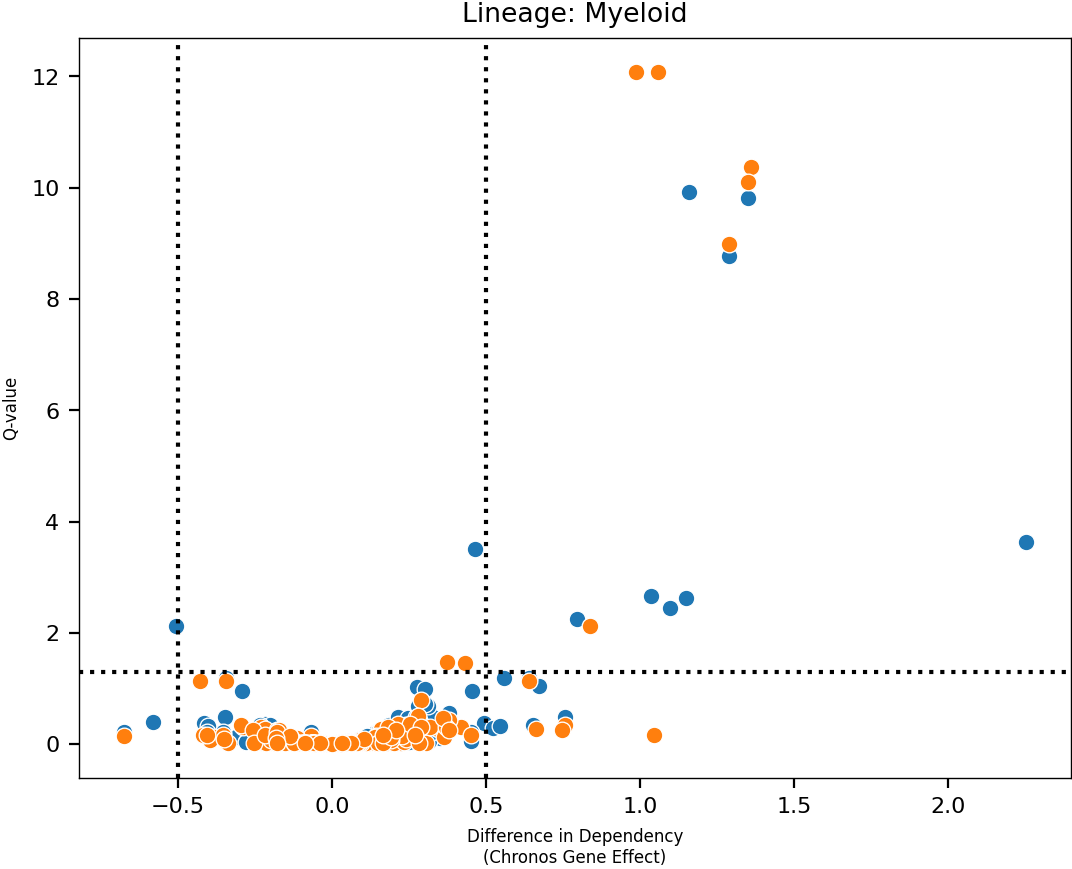

In [201]:
sns.scatterplot(fusion_dependency_df, x = 'gene_1_Difference', y= 'log_gene1_q')
sns.scatterplot(fusion_dependency_df, x = 'gene_2_Difference', y= 'log_gene2_q')
plt.axhline(-1*np.log10(0.05), ls = ':', c= 'k')
plt.axvline(0.5, ls = ':', c= 'k')
plt.axvline(-0.5, ls = ':', c= 'k')
plt.ylabel('Q-value')
plt.xlabel('Difference in Dependency\n(Chronos Gene Effect)')
plt.title('Lineage: Myeloid')
plt.show()

Alright now that we have it functioning for the myeloid lineage let's expand it to the other lineages and ensure each at least has 1 significant dependency. If any of the lineages does not then I will be dropping that lineage for the time being.

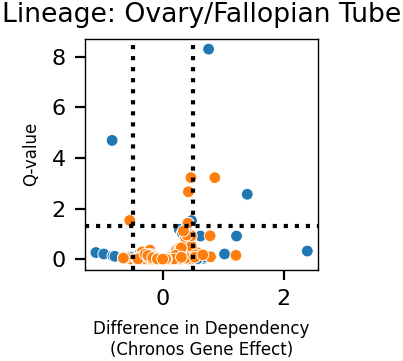

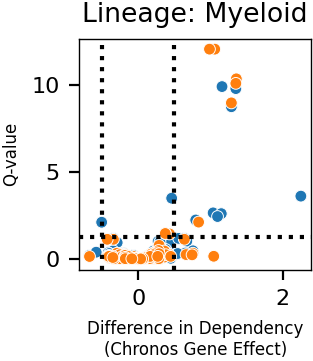

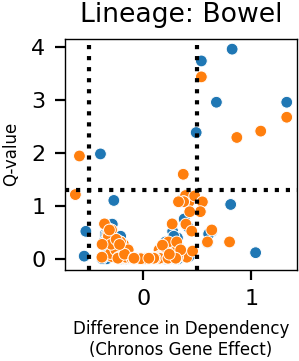

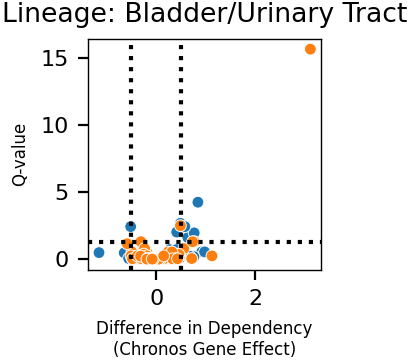

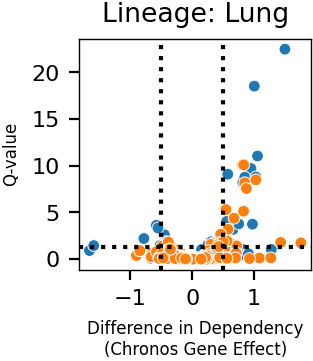

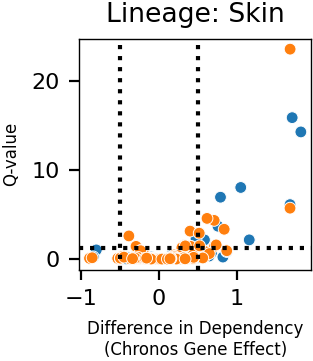

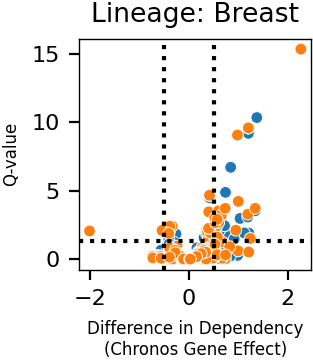

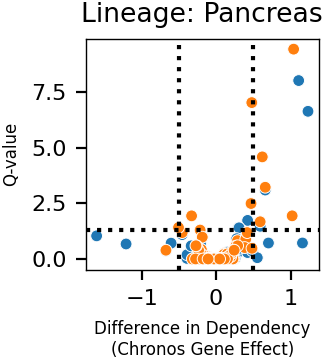

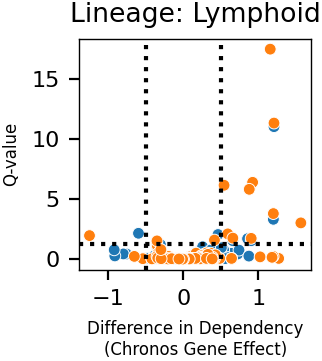

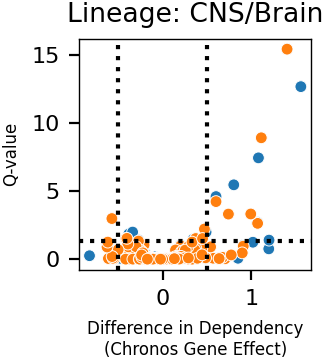

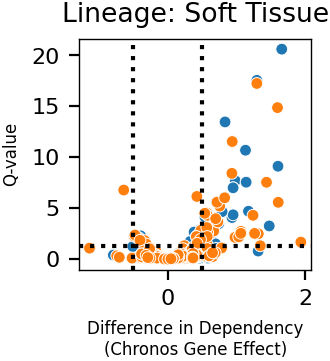

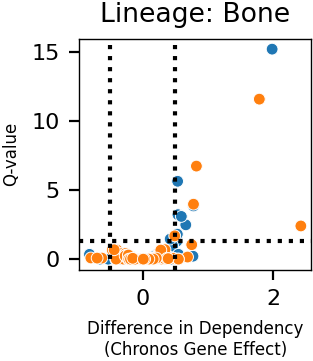

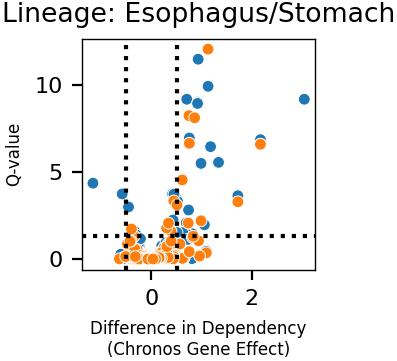

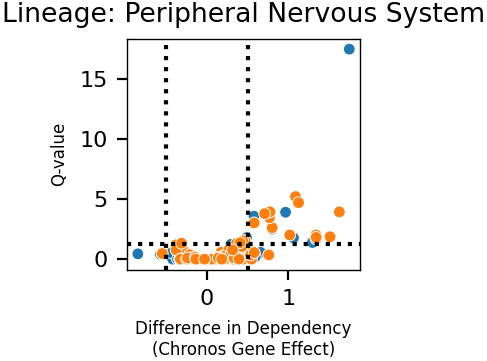

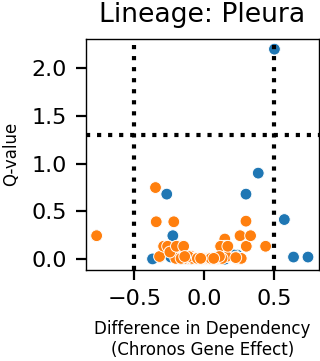

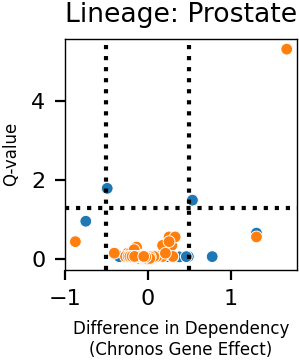

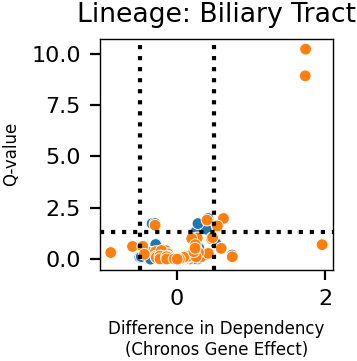

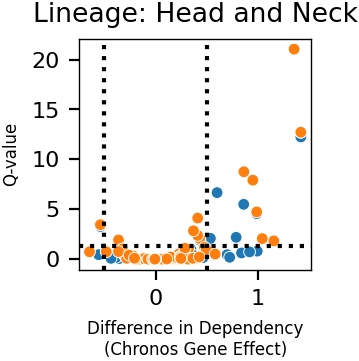

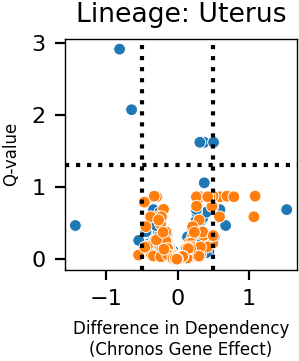

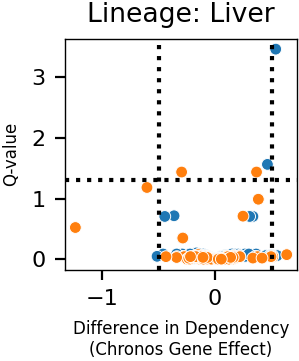

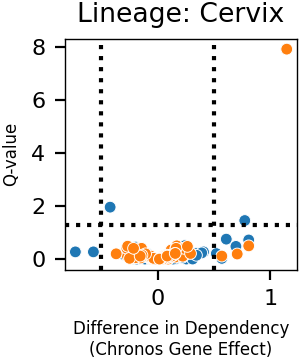

In [209]:
dependency_results = {}
for lineage in lineages2keep:
    lineageOI = dep_analysis_grouped.get_group(lineage)
    x = lineageOI.ModelID
    lineage_fusions = dataOI[dataOI.ModelID.isin(x)]
    genesOI = list(set(lineage_fusions.gene1_symbol).union(lineage_fusions.gene2_symbol))
    c = sorted([colname2gene[i] for i in genesOI if i in colname2gene])
    lineageOI = lineageOI.filter(['ModelID','CellLineName',]+c, axis = 1)
    lineageOI.dropna(axis = 1, inplace=True)
    unique_myleoids = lineage_fusions.filter(['gene1_symbol','gene2_symbol']).drop_duplicates()
    unique_myleoids['fusion'] = unique_myleoids.gene1_symbol.str.cat(unique_myleoids.gene2_symbol, sep = '--')
    unique_myleoids = unique_myleoids.fusion.unique()
    all_dep_res = []
    for f in unique_myleoids:
        gene1,gene2 = f.split('--')

        # Check that names are present in the conversion
        c1 = gene1 in colname2gene
        c2 = gene2 in colname2gene

        # Check if the column names are present
        if c1 and c2:
            c3 = colname2gene[gene1] in lineageOI.columns
            c4 = colname2gene[gene2] in lineageOI.columns
        else:
            c3 = False
            c4 = False

        if c3 and c4:
            o = fusion_partner_dependencies(lineageOI, lineage_fusions, gene1, gene2)
            all_dep_res.append(o)

    fusion_dependency_df =pd.DataFrame.from_records(all_dep_res)
    fusion_dependency_df['gene1_q'] = stats.false_discovery_control(fusion_dependency_df['gene_1_p'], method='bh')
    fusion_dependency_df['gene2_q'] = stats.false_discovery_control(fusion_dependency_df['gene_2_p'], method='bh')
    fusion_dependency_df['log_gene1_q'] = -1*np.log10(fusion_dependency_df['gene1_q'])
    fusion_dependency_df['log_gene2_q'] = -1*np.log10(fusion_dependency_df['gene2_q'])
    fusion_dependency_df['dependency_cat'] = (fusion_dependency_df['gene1_q'] <= 0.05) | (fusion_dependency_df['gene2_q'] <= 0.05)

    if any(fusion_dependency_df.dependency_cat):
        plt.figure(figsize=(1.5,1.5))
        sns.scatterplot(fusion_dependency_df, x = 'gene_1_Difference', y= 'log_gene1_q', size =1)
        sns.scatterplot(fusion_dependency_df, x = 'gene_2_Difference', y= 'log_gene2_q', size = 1)
        plt.gca().get_legend().set_visible(False)
        plt.axhline(-1*np.log10(0.05), ls = ':', c= 'k')
        plt.axvline(0.5, ls = ':', c= 'k')
        plt.axvline(-0.5, ls = ':', c= 'k')
        plt.ylabel('Q-value')
        plt.xlabel('Difference in Dependency\n(Chronos Gene Effect)')
        plt.title(f'Lineage: {lineage}')
        plt.show()

    dependency_results[lineage] = fusion_dependency_df.copy()

In [216]:
ccle_group.get_group(('ENSG00000004399-ENSG00000172765', 'No Change', 'IPR001627|IPR016201|IPR041019|IPR016201'))

,name,h_gene,t_gene,h_uniprot,t_uniprot,h_chr,t_chr,h_pos,t_pos,h_strand,t_strand,id,domain_architecture,ModelID,dansy_impact,ENSEMBL_Combo,Original_Index
8543,PLXND1--TMCC1,ENSG00000004399,ENSG00000172765,Q9Y4D7,O94876,chr3,chr3,129578329,129671264,-,-,DANSY_69710,IPR001627|IPR016201|IPR041019|IPR016201,ACH-000111,No Change,ENSG00000004399-ENSG00000172765,69710
8544,PLXND1--TMCC1,ENSG00000004399,ENSG00000172765,Q9Y4D7,O94876,chr3,chr3,129575766,129671264,-,-,DANSY_69711,IPR001627|IPR016201|IPR041019|IPR016201,ACH-000111,No Change,ENSG00000004399-ENSG00000172765,69711


# Refined analysis that cleans up the connections of datasets being used together.

Because I have had several filters and groupings of similar datasets with slightly different variations of what is kept and whatnot, below this is a restart of the analysis. Here, the order of filtering will go with grabbing all fusions as done before, but filtering them first with the cell lines that have had the CRISPR screen. These then will undergo the DANSy analysis to create groups of fusion-gene::DANSy_Impact::Domain_Architecture. These groups will then be used within individual lineages to test how the DANSy impact the gene effect scores. General trends that are visible by eye will then be checked against the expression results above.

<a id='refined_analysis'></a>

In [58]:
# Reloading some of the raw data

ccle_fusions = pd.read_csv('CCLE_OmicsFusionFilteredSupplementary.csv', index_col=0)
ccle_model_info = pd.read_csv('CCLE_Model.csv')

# A little bit of pre-filtering to remove any of the out of frame fusions because predicting their domain architecture is not accurate
ccle_fusions = ccle_fusions[ccle_fusions['reading_frame'] != 'out-of-frame']

# Additionally removing low confidence fusions and any with FFPM value < 0.1 a general cutoff for fusion artifacts
ccle_fusions = ccle_fusions[ccle_fusions['confidence'] == 'high']
ccle_fusions = ccle_fusions[ccle_fusions['FFPM'] >= 0.1]

# Now let's create a new dataframe that has only relevant information for the time being that can then be passed on to create a fusion gene collection object.
dataOI = ccle_fusions.filter(['ModelID','CanonicalFusionName', 'gene1(ENS ID)', 'gene2(ENS ID)','strand1(gene/fusion)', 'strand2(gene/fusion)','breakpoint1', 'breakpoint2']).copy()
dataOI[['gene1_symbol','gene1_ensembl'] ]= dataOI['gene1(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI[['gene2_symbol','gene2_ensembl']] = dataOI['gene2(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI['gene1_symbol']=dataOI['gene1_symbol'].str.strip()
dataOI['gene2_symbol']=dataOI['gene2_symbol'].str.strip()
dataOI['gene1_ensembl']=dataOI['gene1_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['gene2_ensembl']=dataOI['gene2_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['strand1'] = dataOI['strand1(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI['strand2'] = dataOI['strand2(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI[['gene1_chr','gene1_pos']] = dataOI['breakpoint1'].str.split(':', n=1, expand=True)
dataOI[['gene2_chr','gene2_pos']] = dataOI['breakpoint2'].str.split(':', n=1, expand=True)
dataOI['gene1_pos']=dataOI['gene1_pos'].astype(int)
dataOI['gene2_pos']=dataOI['gene2_pos'].astype(int)

# For a handful of genes they lack an ensembl ID so will try to convert them, but otherwise will drop them
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
gene_conv = gene_conv.filter(['Gene stable ID', 'Gene name'], axis = 1).drop_duplicates()
conv_dict = dict(zip(gene_conv['Gene name'], gene_conv['Gene stable ID']))

# Mapping missing gene ensembl names
dataOI['gene1_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 1) , axis=1)
dataOI['gene2_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 2) , axis=1)
dataOI.dropna(subset=['gene1_ensembl', 'gene2_ensembl'],inplace=True)

In [59]:
# Importing the dependency scores
dep_scores = pd.read_csv('CRISPRGeneEffect.csv')
dep_scores.rename(columns={'Unnamed: 0':'ModelID'}, inplace=True)

# Now let's just filter the columns to those from the fusion genes.
# Getting the fusion genes
allgenes = list(set(dataOI['gene1_symbol']).union(dataOI['gene2_symbol']))

# Now filtering the columns based on whether they were in a fusion
c = [g for g in dep_scores if g.split(' ')[0] in allgenes]
dep_scores = dep_scores.filter(['ModelID']+c, axis = 1)
colname2gene = {x.split(' ')[0]:x for x in dep_scores.columns}
del colname2gene['ModelID']
# now let's integrate the model lineage and names into the dependency scores
dep_analysis = ccle_model_info.filter(['ModelID','CellLineName','OncotreeLineage']).merge(dep_scores, left_on='ModelID',right_on = 'ModelID')
# Let's only keep lineages with >= 10 models
lineages2keep = [k for k,v in Counter(dep_analysis.OncotreeLineage).items() if v >= 10]

# Run through and get groups for the dependency score analysis and then use the BCR-ABL for the time being as a model of the larger framework
dep_analysis = dep_analysis[dep_analysis.OncotreeLineage.isin(lineages2keep)]
dep_analysis_grouped = dep_analysis.groupby('OncotreeLineage')

In [60]:
# Now let's grab the model IDs and filter the fusion data to only include models that have the CRISPR data as well.
crispr_lines = dep_analysis.ModelID.unique()
fusions4analysis = dataOI[dataOI.ModelID.isin(crispr_lines)]

In [61]:
# DANSy object of the full natural proteome
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0108.csv')
proteome_net = dansy.dansy(ref=ref_df, n=66)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [62]:
# Now with all the pre-filtering done let's run the DANSy fusion analysis
mappings = {'h_gene':'gene1_ensembl', 't_gene':'gene2_ensembl', 'h_chr':'gene1_chr', 't_chr':'gene2_chr', 'h_strand':'strand1', 't_strand':'strand2', 'name':'CanonicalFusionName', 'h_pos':'gene1_pos', 't_pos':'gene2_pos'}
ccle_fc = fc.fusionCollection(fusions4analysis, mappings, add_cols=['ModelID', 'gene1_symbol','gene2_symbol'])
ccle_fc.perform_dansy_analysis(dansy_obj=proteome_net)
dansy_sum = ccle_fc.summarize_dansy_results()

100%|██████████| 2461/2461 [00:09<00:00, 268.45it/s]


There were 1210 fusion domain architectures previously found in the proteome.


In [63]:
# Now we will take the DANSy results and group them 
dansy_sum['fusion_protein'] = dansy_sum['gene1_symbol'].str.cat(dansy_sum['gene2_symbol'], sep = '--')

# Group these results so that we can then check for how many lineages are represented in a single grouping
dansy_fusion_res = dansy_sum.dropna(subset='dansy_impact').groupby(['fusion_protein','dansy_impact','domain_architecture'])

multilineage_groups = []
# Check for potential multiple lineages:
for group in dansy_fusion_res.groups:
    x = dansy_fusion_res.get_group(group)
    if len(x) > 1:
        models = x.ModelID.unique()
        potential_lineages = ccle_model_info[ccle_model_info.ModelID.isin(models)].OncotreeLineage.unique()
        if len(potential_lineages) > 1:
            print(f'Group {group} with {len(models)} cell lines has multiple lineages and will need to be broken up during analysis.')
            multilineage_groups.append(group)


Group ('ACSL3--PKD1L2', 'No Change', 'IPR046791|IPR013122') with 3 cell lines has multiple lineages and will need to be broken up during analysis.
Group ('AFF1--KMT2A', 'Reintroduction', 'IPR001965|IPR001965|IPR001965|IPR001487|IPR001965|IPR001214|IPR003616') with 3 cell lines has multiple lineages and will need to be broken up during analysis.
Group ('AKAP13--PDE8A', 'No Change', 'IPR057304|IPR000014|IPR002073') with 2 cell lines has multiple lineages and will need to be broken up during analysis.
Group ('AOX1--KCTD18', 'Reinforcement', 'IPR001041|IPR002888|IPR003131|IPR045704') with 11 cell lines has multiple lineages and will need to be broken up during analysis.
Group ('APOBEC3F--APOBEC3B', 'No Change', 'IPR002125|IPR002125') with 2 cell lines has multiple lineages and will need to be broken up during analysis.
Group ('ARHGAP11B--OTUD7A', 'Reinforcement', 'IPR000198|IPR003323|IPR002653') with 9 cell lines has multiple lineages and will need to be broken up during analysis.
Group ('

In [64]:
def fusion_partner_dependencies_predefined_models(dep_df, fusion_models, genefusion, conv = colname2gene):
    
    withfusion = dep_df[dep_df.ModelID.isin(fusion_models)]
    withoutfusion = dep_df[~dep_df.ModelID.isin(fusion_models)]

    gene1, gene2 = genefusion.split('--')

    # Stats test
    g1p = stats.ttest_ind(withfusion[conv[gene1]], withoutfusion[conv[gene1]]).pvalue
    g2p = stats.ttest_ind(withfusion[conv[gene2]], withoutfusion[conv[gene2]]).pvalue

    # Calculating difference
    g1diff = withoutfusion[conv[gene1]].mean() - withfusion[conv[gene1]].mean()
    g2diff = withoutfusion[conv[gene2]].mean() - withfusion[conv[gene2]].mean()

    # Now place into a Series
    output = pd.Series([gene1, g1diff, g1p, gene2, g2diff, g2p], index = ['gene_1','gene_1_Difference','gene_1_p','gene_2','gene_2_Difference','gene_2_p'])

    return output

def check_fusion_columns(fusion, df:pd.DataFrame, conv= colname2gene):

    genes = fusion.split('--')
    conversion_possible = [g in conv for g in genes]

    if all(conversion_possible):
        colexist = [conv[g] in df.dropna(axis=1).columns for g in genes]
    else:
        colexist = [False]

    return all(colexist)


In [65]:
# Now getting the dependencies for each of the fusion groups
dep_res = []
for group in dansy_fusion_res.groups:
    x = dansy_fusion_res.get_group(group)
    models = x.ModelID.unique()
    potential_lineages = ccle_model_info[ccle_model_info.ModelID.isin(models)].OncotreeLineage.unique()
    for lineage in potential_lineages:
        lineage_dep = dep_analysis_grouped.get_group(lineage)
        if check_fusion_columns(group[0], lineage_dep):
            diff_dep_res = fusion_partner_dependencies_predefined_models(lineage_dep, models, group[0])
            diff_dep_res['Lineage'] = lineage
            diff_dep_res['N'] = len(set(models).intersection(lineage_dep.ModelID))
            temp = pd.Series(group, index = ['fusion_protein','dansy_impact','domain_architecture'])
            diff_dep_res = pd.concat([temp,diff_dep_res])
            dep_res.append(diff_dep_res)


In [66]:
dep_res_full = pd.DataFrame.from_records(dep_res)
for i in ['gene_1', 'gene_2']:
    dep_res_full[i+'_q'] = stats.false_discovery_control(dep_res_full[i+'_p'], method='bh')
    dep_res_full['log_'+i+'_q'] = -1*np.log10(dep_res_full[i+'_q'])

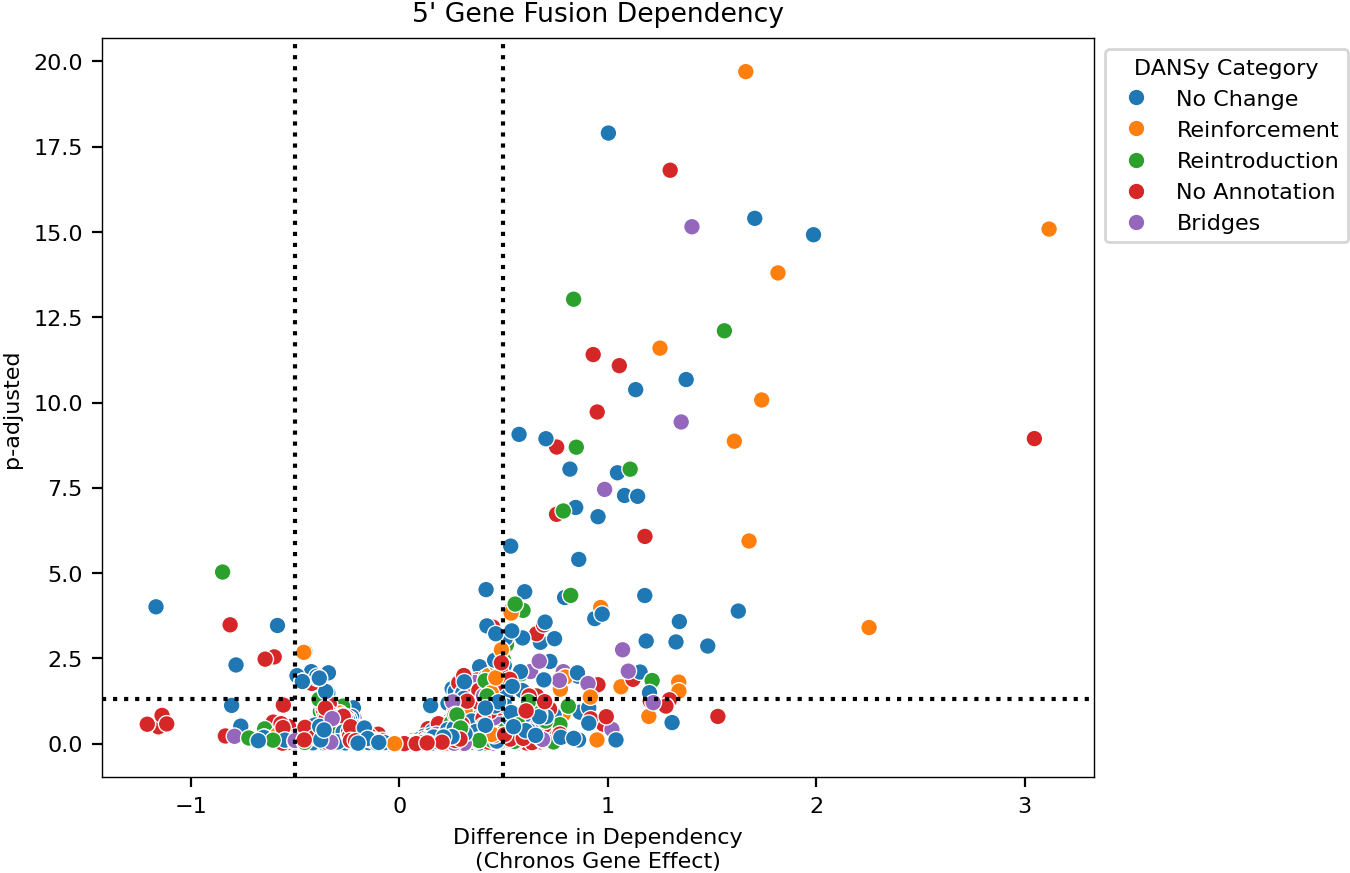

In [72]:
sns.scatterplot(dep_res_full, x = 'gene_1_Difference', y = 'log_gene_1_q', hue = 'dansy_impact')
plt.axhline(-1*np.log10(0.05), ls = ':', c= 'k')
plt.axvline(0.5, ls = ':', c= 'k')
plt.axvline(-0.5, ls = ':', c= 'k')
l = plt.gca().get_legend()
l.set_bbox_to_anchor((1,1))
l.set_title('DANSy Category')
plt.ylabel('p-adjusted', size = 8)
plt.xlabel('Difference in Dependency\n(Chronos Gene Effect)', size = 8)
plt.title('5\' Gene Fusion Dependency')
plt.show()

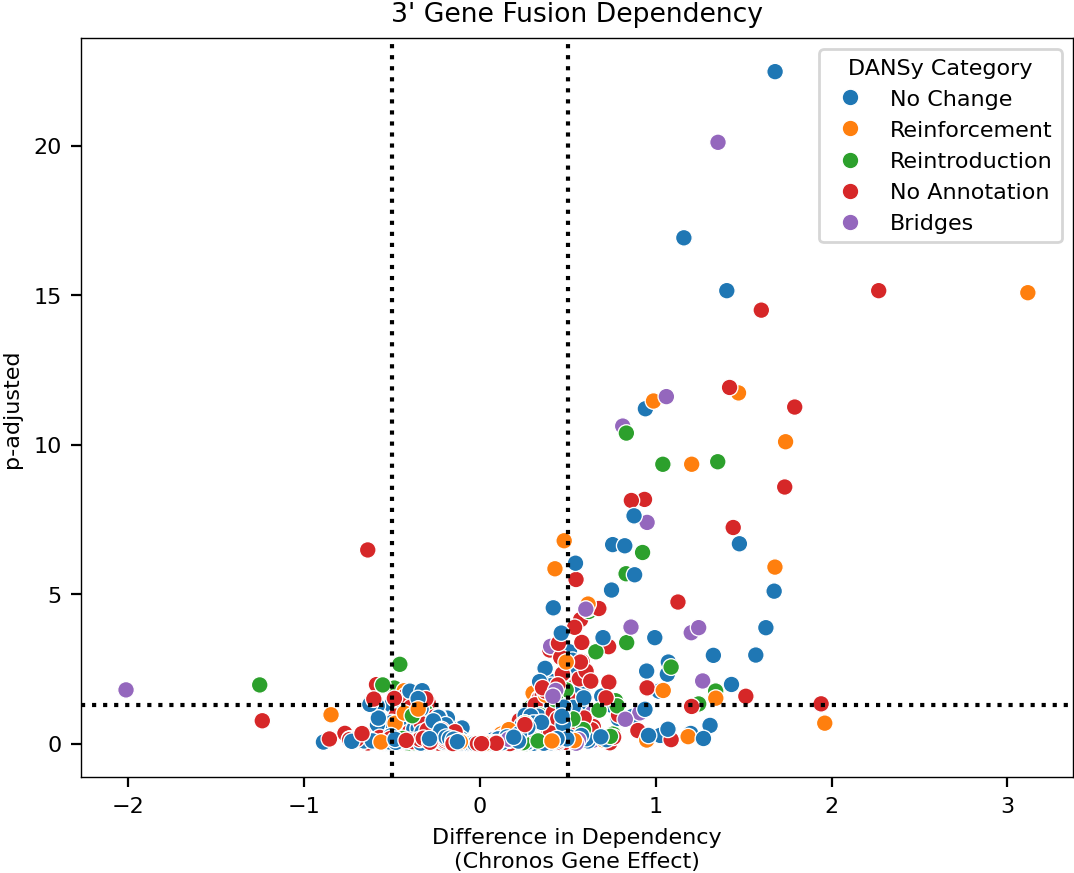

In [73]:
sns.scatterplot(dep_res_full, x = 'gene_2_Difference', y = 'log_gene_2_q', hue = 'dansy_impact')
plt.axhline(-1*np.log10(0.05), ls = ':', c= 'k')
plt.axvline(0.5, ls = ':', c= 'k')
plt.axvline(-0.5, ls = ':', c= 'k')
l = plt.gca().get_legend()
l.set_bbox_to_anchor((1,1))
l.set_title('DANSy Category')
plt.ylabel('p-adjusted', size = 8)
plt.xlabel('Difference in Dependency\n(Chronos Gene Effect)', size = 8)
plt.title('3\' Gene Fusion Dependency')
plt.show()

In [41]:
dep_res_full.columns

Index(['fusion_protein', 'dansy_impact', 'domain_architecture', 'gene_1',
       'gene_1_Difference', 'gene_1_p', 'gene_2', 'gene_2_Difference',
       'gene_2_p', 'Lineage', 'N', 'gene_1_q', 'log_gene_1_q', 'gene_2_q',
       'log_gene_2_q'],
      dtype='object')

In [42]:
# Let's look at how many of the fusions are within the quadrant of interest (>0.5 diff and q-val <0.05)
dep_res_full['Quad_OI'] = dep_res_full.apply(lambda row: all([any([row['gene_1_Difference'] >= 0.5, row['gene_2_Difference'] >= 0.5]),any([row['gene_1_q'] <= 0.05, row['gene_2_q'] <= 0.05])]), axis =1)

In [43]:
dep_res_full

,fusion_protein,dansy_impact,domain_architecture,gene_1,gene_1_Difference,gene_1_p,gene_2,gene_2_Difference,gene_2_p,Lineage,N,gene_1_q,log_gene_1_q,gene_2_q,log_gene_2_q,Quad_OI
0,A4GALT--A4GALT,No Change,IPR007652,A4GALT,-0.038160,0.800646,A4GALT,-0.038160,0.800646,Bone,1,0.998483,0.000659,0.994124,0.002559,False
1,A4GALT--CRYBB1,No Change,IPR001064|IPR001064,A4GALT,-0.308086,0.011623,CRYBB1,-0.130330,0.232514,Lung,1,0.185042,0.732729,0.866736,0.062113,False
2,AACS--DHX37,Reinforcement,IPR032387|IPR007502|IPR011709|IPR056371,AACS,0.292559,0.026027,DHX37,0.263417,0.469334,Skin,1,0.326672,0.485888,0.971671,0.012481,False
3,AARS1--MTSS2,No Change,IPR003124,AARS1,0.254768,0.503249,MTSS2,-0.024980,0.756438,Cervix,1,0.979786,0.008869,0.994124,0.002559,False
4,AATK--CEP131,No Change,IPR000719,AATK,-0.044194,0.760072,CEP131,0.058049,0.810227,Breast,1,0.998483,0.000659,0.994124,0.002559,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4580,ZSCAN22--CHMP2A,No Annotation,,ZSCAN22,0.025349,0.828153,CHMP2A,-0.153623,0.686420,Lung,1,0.998483,0.000659,0.994124,0.002559,False
4581,ZSWIM4--RFX1,Reinforcement,IPR007527|IPR007668|IPR003150|IPR057321,ZSWIM4,-0.021498,0.766514,RFX1,-0.111721,0.236907,Lung,2,0.998483,0.000659,0.871947,0.059510,False
4582,ZYG11A--SCP2,No Change,IPR003033,ZYG11A,-0.097891,0.317649,SCP2,-0.128421,0.225810,Breast,1,0.922549,0.035011,0.859917,0.065544,False
4583,ZZZ3--MIGA1,No Annotation,,ZZZ3,0.081659,0.668994,MIGA1,0.092492,0.472590,Liver,1,0.998483,0.000659,0.971671,0.012481,False


In [44]:
dansy_fusion_res.get_group(('CLTC--VMP1','No Annotation',''))
#ccle_fc.get_fusion('DANSY_77638').h_contribution


,name,h_gene,t_gene,h_uniprot,t_uniprot,h_chr,t_chr,h_pos,t_pos,h_strand,t_strand,id,domain_architecture,ModelID,gene1_symbol,gene2_symbol,dansy_impact,fusion_protein
2730,CLTC--VMP1,ENSG00000141367,ENSG00000062716,Q00610,Q96GC9,chr17,chr17,59648401,59817712,+,+,DANSY_77638,,ACH-000609,CLTC,VMP1,No Annotation,CLTC--VMP1
2749,CLTC--VMP1,ENSG00000141367,ENSG00000062716,Q00610,Q96GC9,chr17,chr17,59651316,59808796,+,+,DANSY_78210,,ACH-000472,CLTC,VMP1,No Annotation,CLTC--VMP1
2958,CLTC--VMP1,ENSG00000141367,ENSG00000062716,Q00610,Q96GC9,chr17,chr17,59656027,59839768,+,+,DANSY_83148,,ACH-000548,CLTC,VMP1,No Annotation,CLTC--VMP1
3826,CLTC--VMP1,ENSG00000141367,ENSG00000062716,Q00610,Q96GC9,chr17,chr17,59648401,59839768,+,+,DANSY_104654,,ACH-000696,CLTC,VMP1,No Annotation,CLTC--VMP1
4144,CLTC--VMP1,ENSG00000141367,ENSG00000062716,Q00610,Q96GC9,chr17,chr17,59620173,59811670,+,+,DANSY_111786,,ACH-000976,CLTC,VMP1,No Annotation,CLTC--VMP1
6838,CLTC--VMP1,ENSG00000141367,ENSG00000062716,Q00610,Q96GC9,chr17,chr17,59620173,59839768,+,+,DANSY_183250,,ACH-000973,CLTC,VMP1,No Annotation,CLTC--VMP1


In [45]:
ccle_fusions.loc[77638]

SequencingID                                 CDS-QJg9Tx
ModelID                                      ACH-000609
IsDefaultEntryForModel                              Yes
ModelConditionID                         MC-000609-rR5h
IsDefaultEntryForMC                                 Yes
CanonicalFusionName                          CLTC--VMP1
gene1(ENS ID)                 CLTC (ENSG00000141367.12)
gene2(ENS ID)                 VMP1 (ENSG00000062716.13)
TotalReadsInSample                             62652010
TotalReadsSupportingFusion                          133
FFPM                                           2.122837
confidence                                         high
split_reads1                                         36
split_reads2                                         53
discordant_mates                                     44
strand1(gene/fusion)                                +/+
strand2(gene/fusion)                                +/+
reading_frame                                  i

In [46]:
ref_df

,UniProt ID,Gene,Species,Uniprot Domains,Ref Sequence,PDB IDs,Uniprot Domain Architecture,Interpro Domains,Interpro Domain Architecture,Interpro Domain Architecture IDs
0,Q9H339,OR51B5,Homo sapiens,,MSSSGSSHPFLLTGFPGLEEAHHWISVFFLFMYISILFGNGTLLLL...,,,GPCR_Rhodpsn_7TM:IPR017452:39:290,GPCR_Rhodpsn_7TM,IPR017452
1,Q6ZUS5,CCDC121,Homo sapiens,,MTDLNKHIKQAQTQRKQLLEESRELHREKLLVQAENRFFLEYLTNK...,,,DUF4515:IPR032777:35:240,DUF4515,IPR032777
2,Q6ZRC1,C4orf50,Homo sapiens,,MEPTAKGRTEESFSYVIRAPSSEGFDIMNVDVKIDTSWIFQDMEDS...,,,,,
3,P51168,SCNN1B,Homo sapiens,,MHVKKYLLKGLHRLQKGPGYTYKELLVWYCDNTNTHGPKRIICEGP...,6BQN;6WTH;9BLR;9BTG;9BTU,,,,
4,Q9C056,NKX6-2,Homo sapiens,,MDTNRPGAFVLSSAPLAALHNMAEMKTSLFPYALQGPAGFKAPALG...,,,HD:IPR001356:146:210,HD,IPR001356
...,...,...,...,...,...,...,...,...,...,...
20415,P19235,EPOR,Homo sapiens,Fibronectin type-III:147:247,MDHLGASLWPQVGSLCLLLAGAAWAPPPNLPDPKFESKAALLAARG...,1CN4;1EBA;1EBP;1EER;1ERN;2JIX;2MV6;4Y5V;4Y5X;4...,Fibronectin type-III,Growth/epo_recpt_lig-bind:IPR015152:37:140;FN3...,Growth/epo_recpt_lig-bind|FN3_dom,IPR015152|IPR003961
20416,Q8NFY9,KBTBD8,Homo sapiens,BTB:49:117;BACK:153:252,MAASADLSKSSPTPNGIPSSDPASDAMDPFHACSILKQLKTMYDEG...,,BTB|BACK,BTB/POZ_dom:IPR000210:40:147;BACK:IPR011705:15...,BTB/POZ_dom|BACK,IPR000210|IPR011705
20417,P08621,SNRNP70,Homo sapiens,RRM:103:181,MTQFLPPNLLALFAPRDPIPYLPPLEKLPHEKHHNQPYCGIAPYIR...,2L5I;2L5J;3CW1;3PGW;4PJO;4PKD;6QX9;7B0Y;7VPX;8R08,RRM,U1snRNP70_N:IPR022023:3:94;RRM_dom:IPR000504:1...,U1snRNP70_N|RRM_dom,IPR022023|IPR000504
20418,Q9UGF7,OR12D3,Homo sapiens,,MENVTTMNEFLLLGLTGVQELQPFFFGIFLIIYLINLIGNGSILVM...,,,GPCR_Rhodpsn_7TM:IPR017452:39:289,GPCR_Rhodpsn_7TM,IPR017452


### Trying an alternative approach for designating the fusion is "essential" or has a functional effect on cell viability when removed.

Here to mostly explore the statistical power of the fusion, I will be doing a KS-like test on randomly permutating the cell lines designated as having a fusion and which 2 genes are part of the fusion. This can give me a distribution of the mean difference in dependency scores can alleviate some of my concerns on the assumptions made with relying on a t-test with equal variance.

The steps go as follows:
1. Compute the mean differential dependency score difference for the fusion gene between cell lines with the fusion and those without.
2. Create 1000 permutations where the same number of cell lines as the fusion in question are designated as having a fusion.
3. For each permutation, randomly choose 2 genes with CRISPR dependency scores.
4. In each permutation calculate a mean differential dependency score difference.
5. Calculate a False Positive Rate
6. Correct for multiple comparisons with the BH method.

In [79]:
import random

In [80]:
# Defining the necessary functions.

def get_mdds(dep_df, fusion_models, genefusion, conv=colname2gene):
    
    withfusion = dep_df[dep_df.ModelID.isin(fusion_models)]
    withoutfusion = dep_df[~dep_df.ModelID.isin(fusion_models)]

    gene1, gene2 = genefusion.split('--')

    # Calculating difference
    g1diff = withoutfusion[conv[gene1]].mean() - withfusion[conv[gene1]].mean()
    g2diff = withoutfusion[conv[gene2]].mean() - withfusion[conv[gene2]].mean()

    mdds = np.mean([g1diff, g2diff])

    return mdds

def create_permutations(dep_df, genefusion, n_models, conv=colname2gene, iters = 1000):

    allmodels = sorted(dep_df.ModelID.unique())
    model_perms = [random.sample(allmodels, k = n_models) for i in range(iters)]
    temp_gene_perms = [random.choices(list(conv.keys()),k = 2) for i in range(iters)] #choices instead because want to account for any duplication events
    gene_perms = ['--'.join(i) for i in temp_gene_perms]
    
    # For the rare case when the gene fusion of interest is recreated
    if genefusion in gene_perms:
        new_fusion = '--'.join(random.choices(list(conv.keys()),k = 2))
        gene_perms[gene_perms == genefusion] = new_fusion

    return [(model_perms[i],gene_perms[i]) for i in range(iters)]

def get_background_dist(dep_df, genefusion,n_models, conv=colname2gene, iters = 1000):

    bckgrnd_perms = create_permutations(dep_df, genefusion, n_models, conv, iters)
    mdds_dist = []
    for model,fusion in bckgrnd_perms:
        mdds_dist.append(get_mdds(dep_df, model, fusion, conv=conv))
    
    return mdds_dist

def calc_fpr(x,dist):
    
    fp = sum([i >= x for i in dist])
    return fp/len(dist)



    


In [81]:
from tqdm import tqdm

In [82]:
random.seed(123)
dep_fpr_res = []
for group in tqdm(dansy_fusion_res.groups):
    x = dansy_fusion_res.get_group(group)
    genes = set(group[0].split('--'))

    models = x.ModelID.unique()
    potential_lineages = ccle_model_info[ccle_model_info.ModelID.isin(models)].OncotreeLineage.unique()
    for lineage in potential_lineages:
        lineage_dep = dep_analysis_grouped.get_group(lineage)
        if check_fusion_columns(group[0], lineage_dep):
            diff_dep_res = pd.Series()
            diff_dep_res['MDDS'] = get_mdds(lineage_dep, models, group[0])
            diff_dep_res['Lineage'] = lineage
            diff_dep_res['N'] = len(set(models).intersection(lineage_dep.ModelID))
            d = get_background_dist(lineage_dep, group[0],diff_dep_res['N'],iters=10)
            diff_dep_res['FPR'] = calc_fpr(diff_dep_res['MDDS'],d)
            temp = pd.Series(group, index = ['fusion_protein','dansy_impact','domain_architecture'])
            diff_dep_res = pd.concat([temp,diff_dep_res])
            dep_fpr_res.append(diff_dep_res)
            


100%|██████████| 4897/4897 [01:58<00:00, 41.28it/s]


In [90]:
dep_fpr_analysis = pd.DataFrame.from_records(dep_fpr_res)
dep_fpr_analysis.FPR = dep_fpr_analysis.FPR.apply(lambda x: x if x > 0 else 0.0001)
dep_fpr_analysis['q'] = stats.false_discovery_control(dep_fpr_analysis.FPR, method='bh')
dep_fpr_analysis['log_q'] = -1*np.log10(dep_fpr_analysis['q'])
dep_fpr_analysis['duplication'] = dep_fpr_analysis['fusion_protein'].apply(lambda x: len(set(x.split('--'))) == 1)
dep_fpr_analysis.sort_values(by = 'MDDS', ascending=False, inplace=True)
dep_fpr_analysis['rank'] = dep_fpr_analysis.MDDS.rank(ascending=False)

In [119]:
hue_order = [i[0] for i in sorted(Counter(dep_fpr_analysis['dansy_impact']).items(), key = lambda x: x[1])]

In [113]:
Counter(dep_fpr_analysis['dansy_impact'])

Counter({'Reinforcement': 400,
         'No Annotation': 1505,
         'No Change': 1833,
         'Bridges': 279,
         'Reintroduction': 568})

In [120]:
hue_order

['Bridges', 'Reinforcement', 'Reintroduction', 'No Annotation', 'No Change']

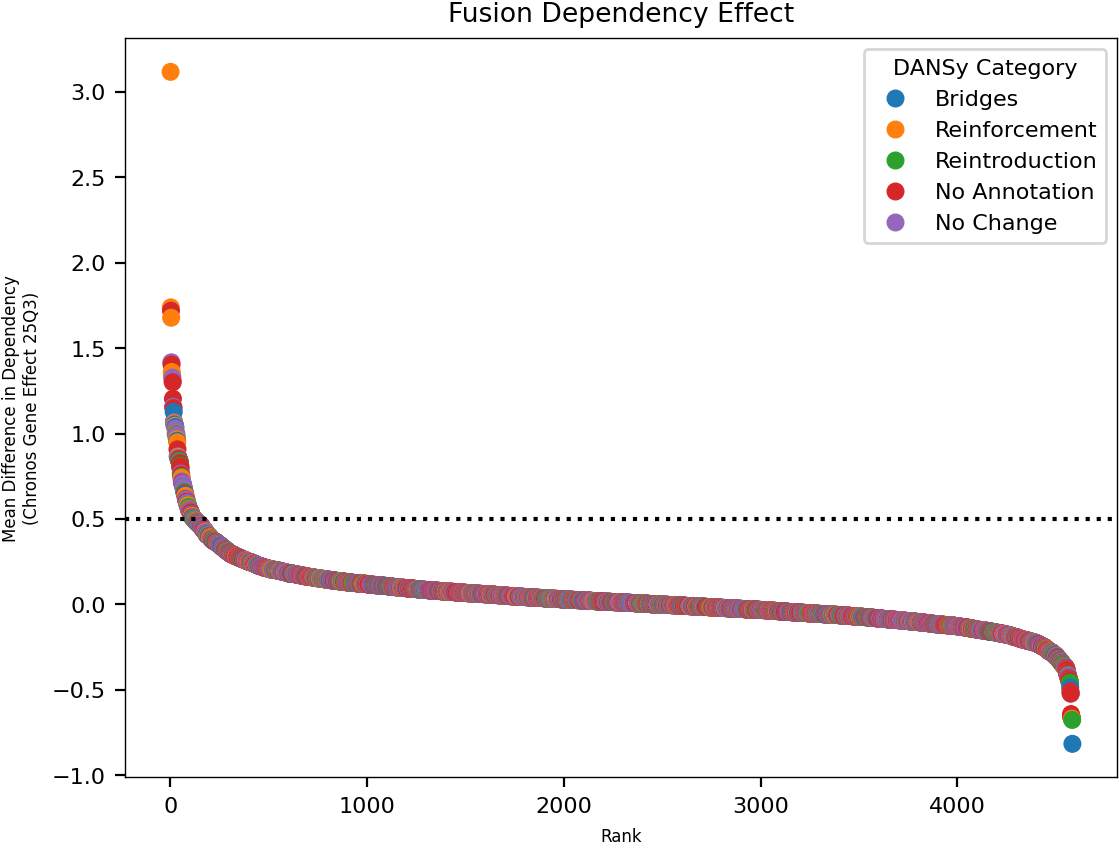

In [121]:
sns.scatterplot(dep_fpr_analysis, x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, hue_order=hue_order)
plt.xlabel('Rank')
plt.ylabel('Mean Difference in Dependency\n(Chronos Gene Effect 25Q3)')
plt.axhline(0.5, ls=':',color = 'k')
plt.title('Fusion Dependency Effect')
l = plt.gca().get_legend()
l.set_title('DANSy Category')
plt.show()

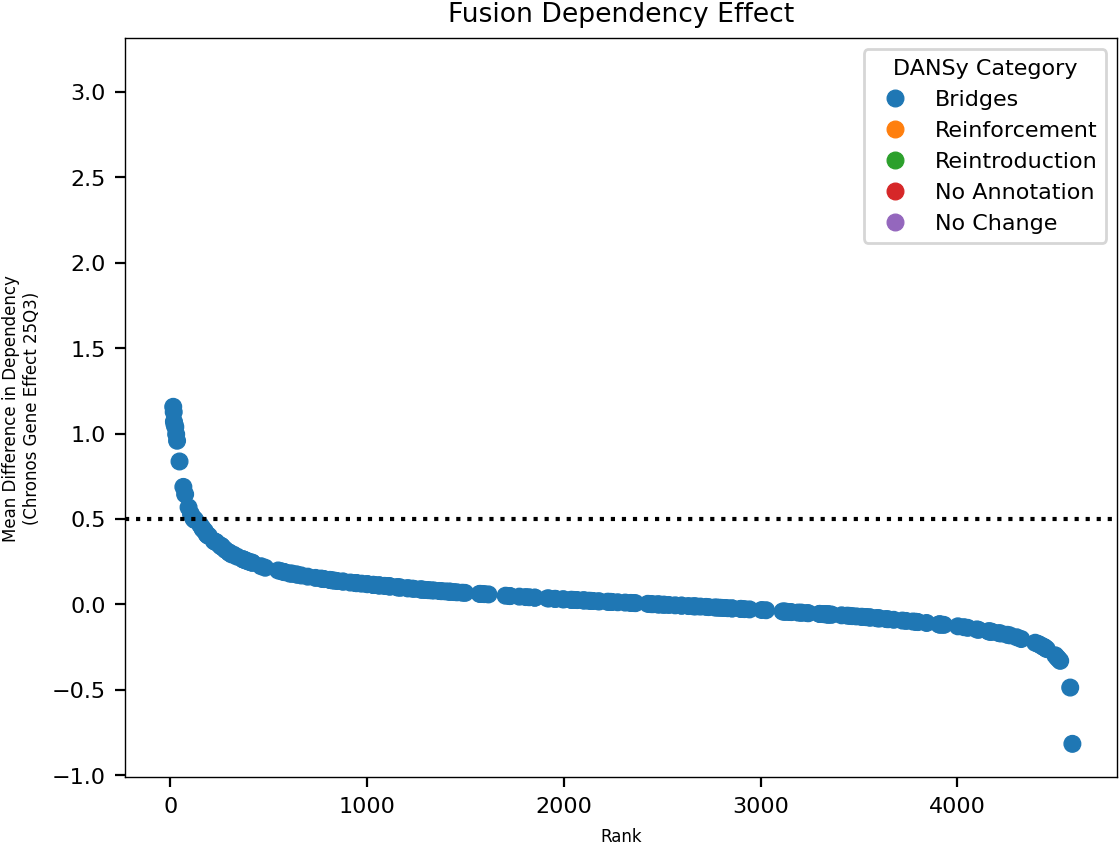

In [123]:
catOI = 'Bridges'
ax = sns.scatterplot(dep_fpr_analysis[dep_fpr_analysis['dansy_impact'] == catOI], x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, alpha = 1, hue_order=hue_order)
sns.scatterplot(dep_fpr_analysis[dep_fpr_analysis['dansy_impact'] != catOI], x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, alpha = 0, ax = ax, hue_order=hue_order, legend=None)
plt.xlabel('Rank')
plt.ylabel('Mean Difference in Dependency\n(Chronos Gene Effect 25Q3)')
plt.axhline(0.5, ls=':',color = 'k')
plt.title('Fusion Dependency Effect')
l = plt.gca().get_legend()
l.set_title('DANSy Category')
plt.show()

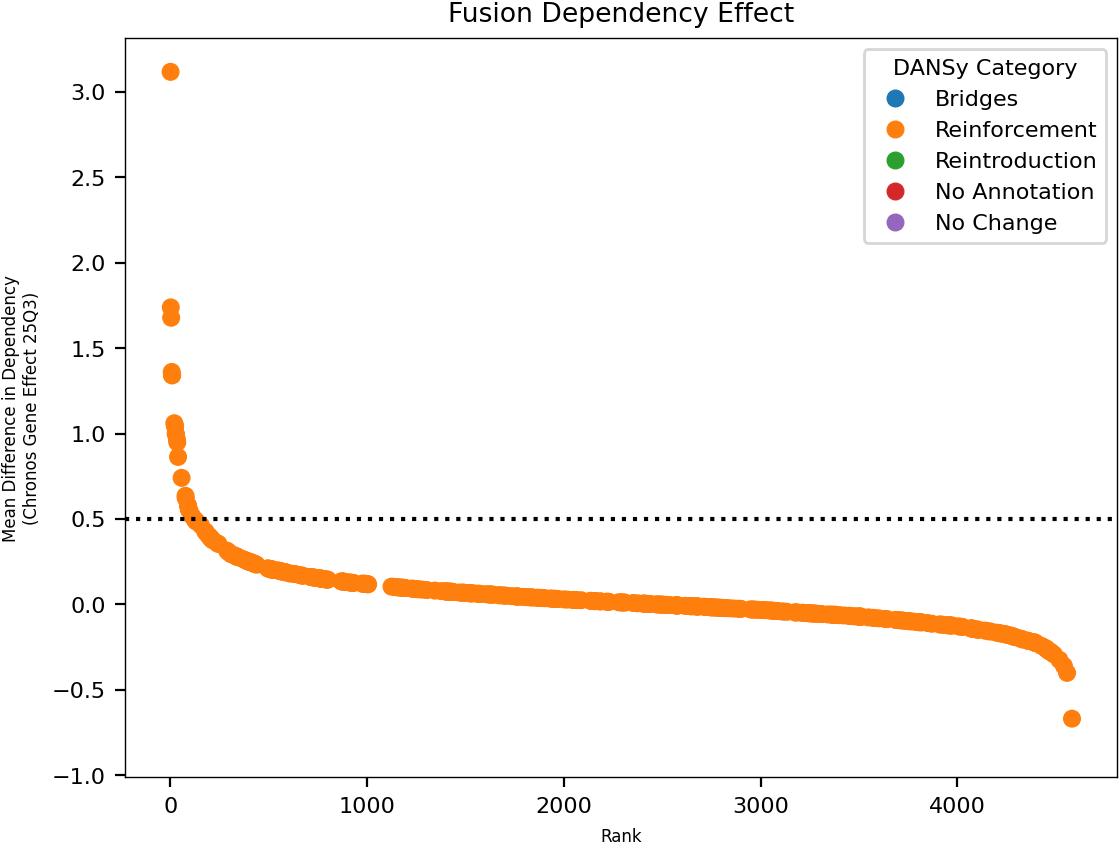

In [125]:
catOI = 'Reinforcement'
ax = sns.scatterplot(dep_fpr_analysis[dep_fpr_analysis['dansy_impact'] == catOI], x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, alpha = 1, hue_order=hue_order)
sns.scatterplot(dep_fpr_analysis[dep_fpr_analysis['dansy_impact'] != catOI], x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, alpha = 0.0, ax = ax, hue_order=hue_order, legend=None)
plt.xlabel('Rank')
plt.ylabel('Mean Difference in Dependency\n(Chronos Gene Effect 25Q3)')
plt.axhline(0.5, ls=':',color = 'k')
plt.title('Fusion Dependency Effect')
l = plt.gca().get_legend()
l.set_title('DANSy Category')
plt.show()

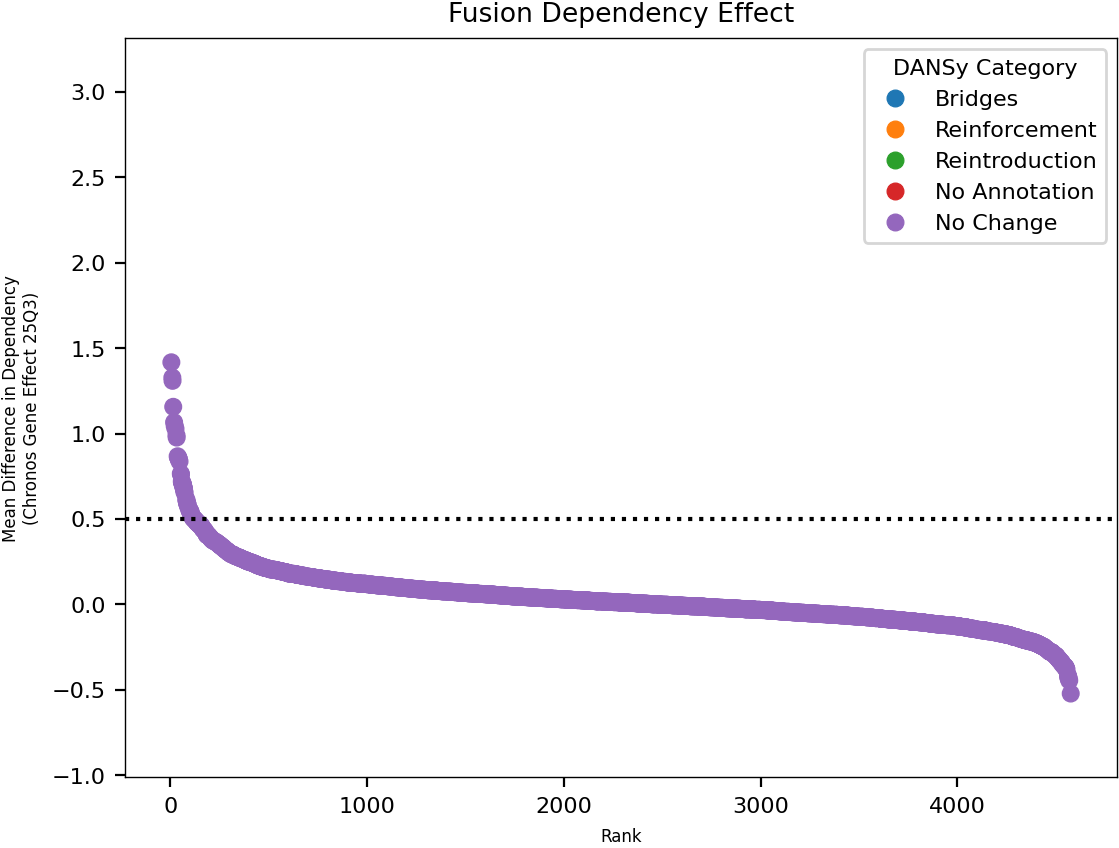

In [126]:
catOI = 'No Change'
ax = sns.scatterplot(dep_fpr_analysis[dep_fpr_analysis['dansy_impact'] == catOI], x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, alpha = 1, hue_order=hue_order)
sns.scatterplot(dep_fpr_analysis[dep_fpr_analysis['dansy_impact'] != catOI], x = 'rank', y = 'MDDS', hue = 'dansy_impact', edgecolor = None, alpha = 0.0, ax = ax, hue_order=hue_order, legend=None)
plt.xlabel('Rank')
plt.ylabel('Mean Difference in Dependency\n(Chronos Gene Effect 25Q3)')
plt.axhline(0.5, ls=':',color = 'k')
plt.title('Fusion Dependency Effect')
l = plt.gca().get_legend()
l.set_title('DANSy Category')
plt.show()

In [127]:
dep_fpr_analysis['potential_dependence'] = dep_fpr_analysis.MDDS > 0.5

In [128]:
dep_fpr_analysis.to_csv('Fusion_dependency_results.csv')

<Axes: xlabel='dansy_impact', ylabel='percent'>

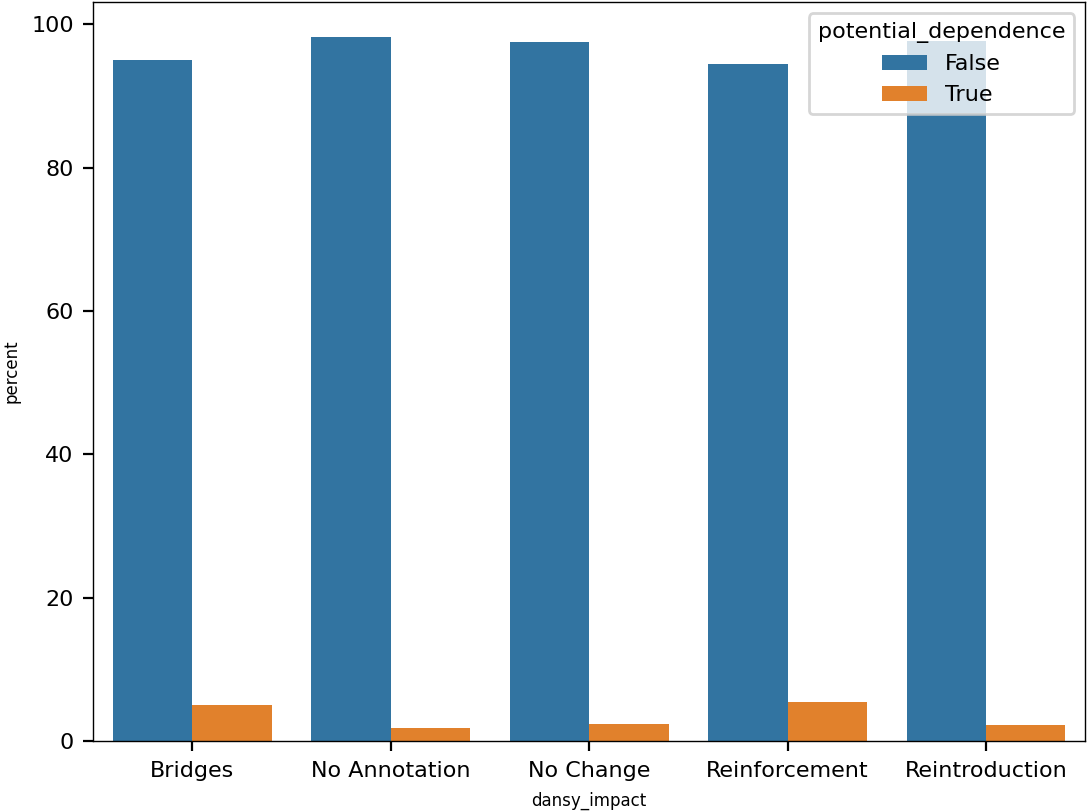

In [129]:
# Doing a quick relative fraction
dep_fpr_analysis.groupby('dansy_impact')['potential_dependence'].value_counts(normalize=True).mul(100).rename('percent').reset_index().pipe((sns.barplot, 'data'),x = 'dansy_impact', y = 'percent', hue = 'potential_dependence', dodge = True)

#sns.countplot(dep_fpr_analysis, x = 'dansy_impact',hue = 'potential_dependence',dodge=False)

In [138]:
dep_fpr_analysis.dansy_impact = pd.Categorical(dep_fpr_analysis.dansy_impact, hue_order)

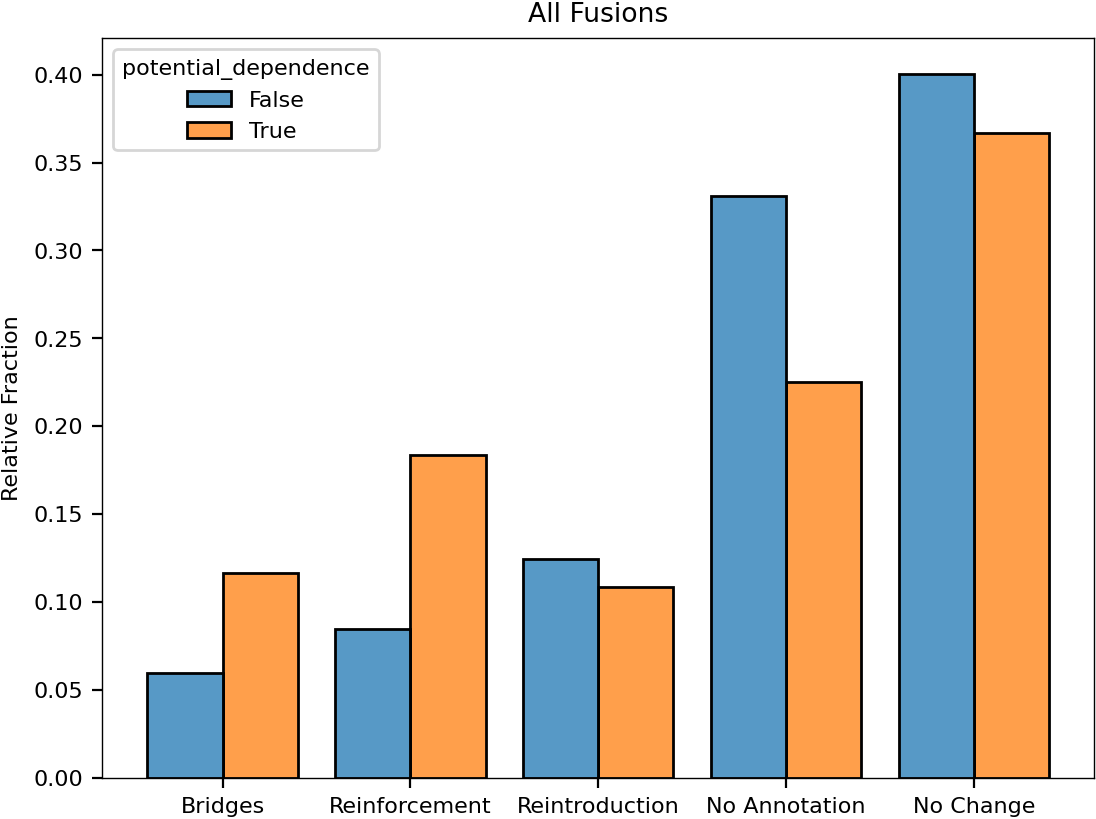

In [143]:
sns.histplot(dep_fpr_analysis, x = 'dansy_impact', hue = 'potential_dependence', multiple='dodge', stat='proportion', common_norm=False, shrink=0.8)
plt.title('All Fusions')
plt.ylabel('Relative Fraction',size = 8)
plt.xlabel(None)
plt.show()


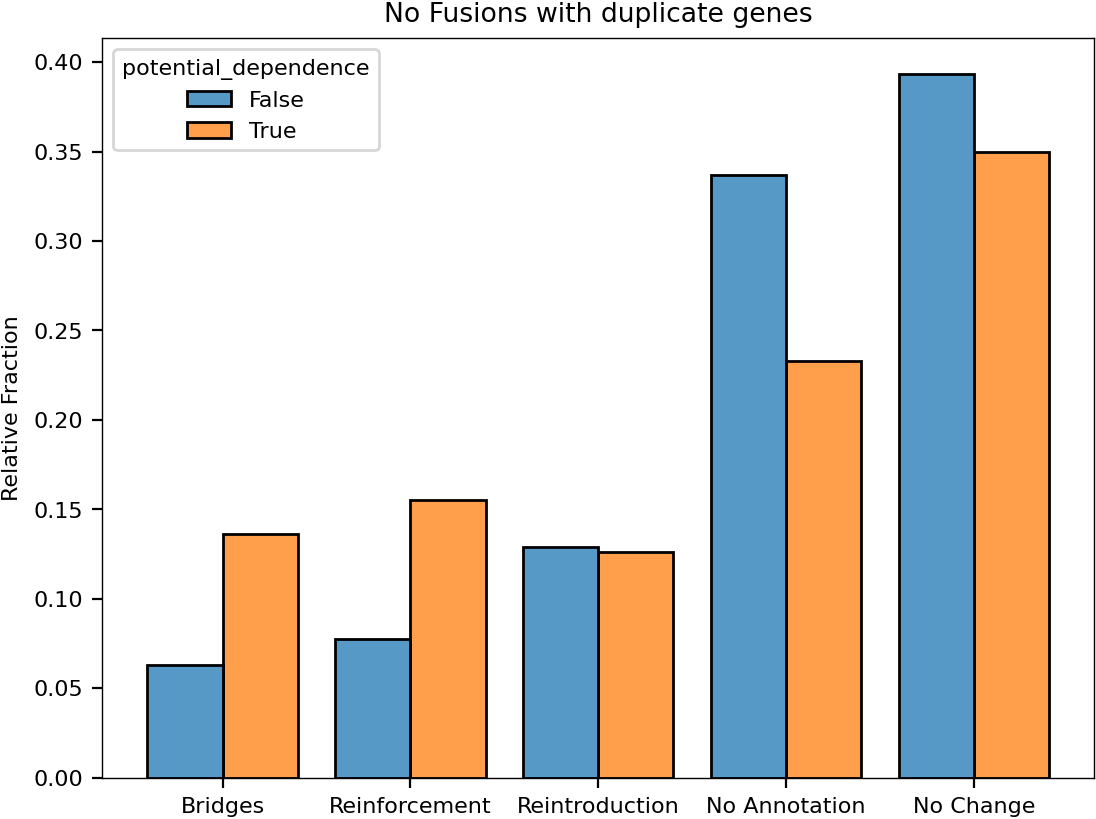

In [144]:
sns.histplot(dep_fpr_analysis[~dep_fpr_analysis.duplication], x = 'dansy_impact', hue = 'potential_dependence', multiple='dodge', stat='proportion', common_norm=False, shrink=0.8)
plt.title('No Fusions with duplicate genes')
plt.ylabel('Relative Fraction',size = 8)
plt.xlabel(None)
plt.show()


<Axes: xlabel='dansy_impact', ylabel='count'>

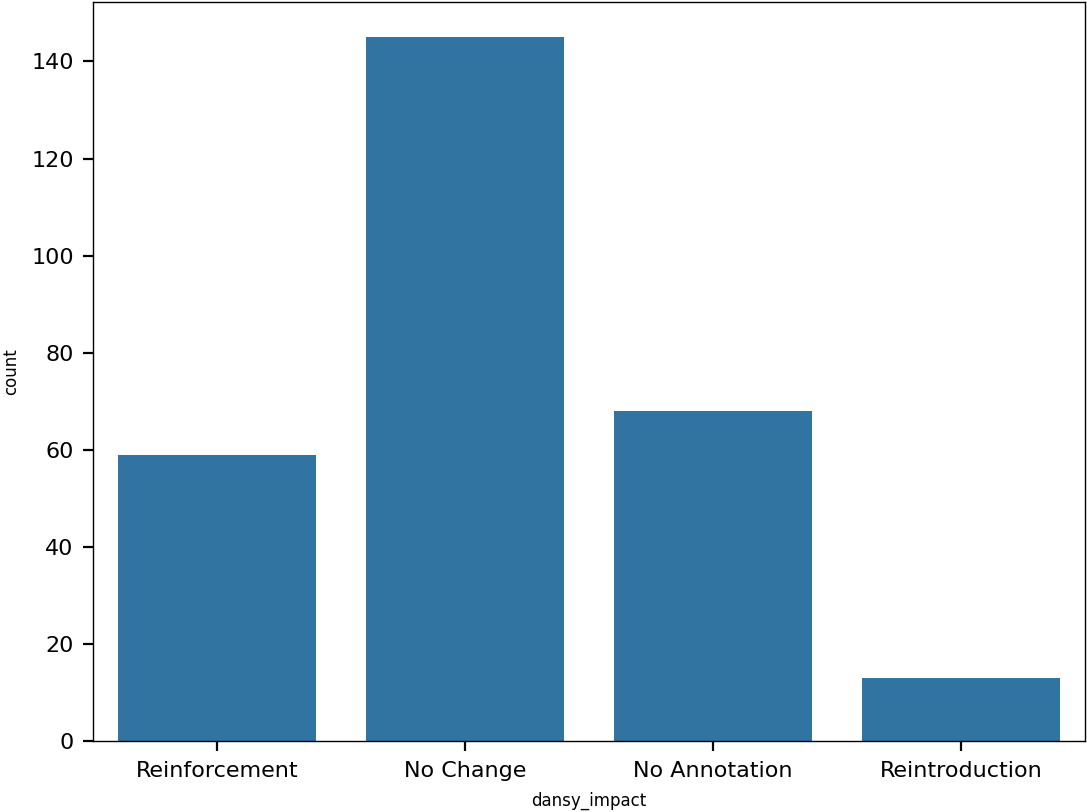

In [442]:
sns.countplot(dep_fpr_analysis[dep_fpr_analysis.duplication],x = 'dansy_impact')